In [3]:
import pandas as pd

In [5]:
sales_csv=pd.read_csv('sales_data_sample.csv',encoding="latin1")
df=pd.DataFrame(sales_csv)

In [6]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [7]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [13]:
sale=df['SALES'].sum()
sale

10032628.85

In [14]:
year=df['YEAR_ID'].unique()
year

array([2003, 2004, 2005], dtype=int64)

In [15]:
sales_year=df.groupby('YEAR_ID')["SALES"].sum()
sales_year

YEAR_ID
2003    3516979.54
2004    4724162.60
2005    1791486.71
Name: SALES, dtype: float64

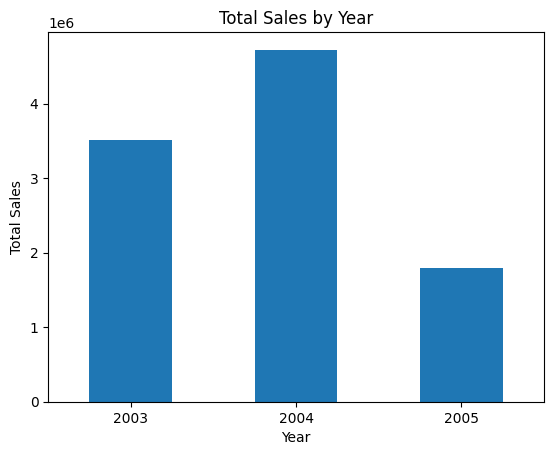

In [16]:
import matplotlib.pyplot as plt
sales_year.plot(kind='bar')
plt.xlabel('Year')  
plt.ylabel('Total Sales')
plt.title('Total Sales by Year')
plt.xticks(rotation=0)
plt.show()


In [17]:
country_sales=df.groupby('COUNTRY')['SALES'].sum()
country_sales

COUNTRY
Australia       630623.10
Austria         202062.53
Belgium         108412.62
Canada          224078.56
Denmark         245637.15
Finland         329581.91
France         1110916.52
Germany         220472.09
Ireland          57756.43
Italy           374674.31
Japan           188167.81
Norway          307463.70
Philippines      94015.73
Singapore       288488.41
Spain          1215686.92
Sweden          210014.21
Switzerland     117713.56
UK              478880.46
USA            3627982.83
Name: SALES, dtype: float64

In [24]:
country_sales_year=df.groupby(['COUNTRY', 'YEAR_ID'])['SALES'].sum().unstack()
country_sales_year

YEAR_ID,2003,2004,2005
COUNTRY,,,
Australia,253134.45,232396.68,145091.97
Austria,82117.88,51694.39,68250.26
Belgium,3348.46,80024.05,25040.11
Canada,54609.50,135776.09,33692.97
Denmark,99192.72,120431.56,26012.87
Finland,111154.51,91575.69,126851.71
France,312761.42,555198.70,242956.40
Germany,70053.31,150418.78,NaN
Ireland,NaN,57756.43,NaN


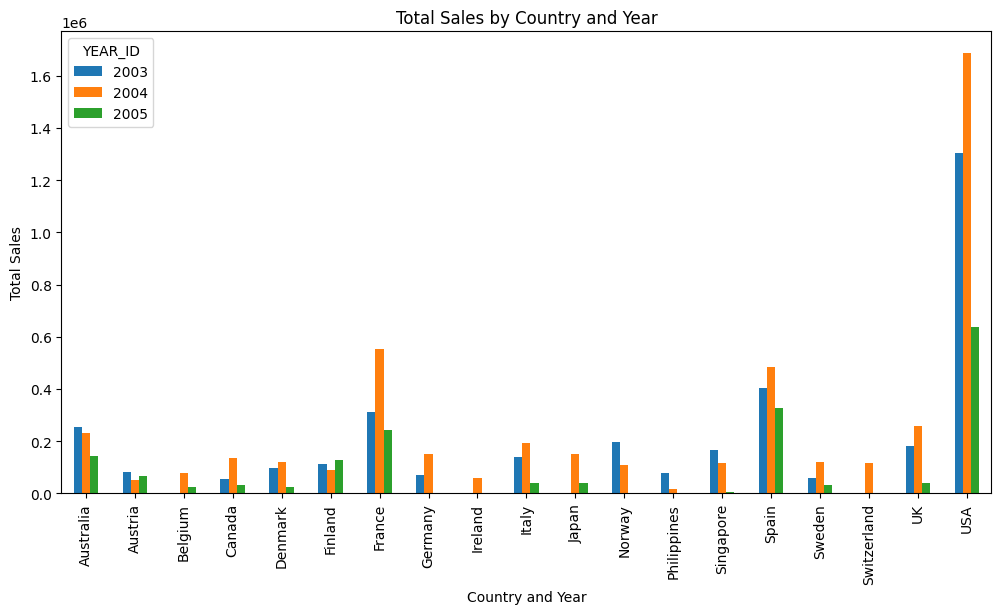

In [40]:
country_sales_year.plot(kind='bar',figsize=(12,6))
plt.xlabel('Country and Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Country and Year')
plt.xticks(rotation=90)
plt.show()

In [27]:
monthly_sales=df.groupby('MONTH_ID')['SALES'].sum()
monthly_sales

MONTH_ID
1      785874.44
2      810441.90
3      754501.39
4      669390.96
5      923972.56
6      454756.78
7      514875.97
8      659310.57
9      584724.27
10    1121215.22
11    2118885.67
12     634679.12
Name: SALES, dtype: float64

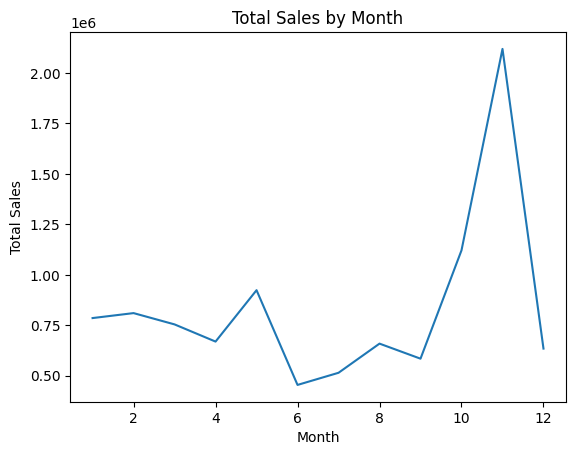

In [30]:
monthly_sales.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Total Sales by Month')
plt.xticks(rotation=0)
plt.show()

In [33]:
top_country=country_sales_year.sum(axis=1).sort_values(ascending=False).head(10)

In [34]:
top_country

COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
dtype: float64

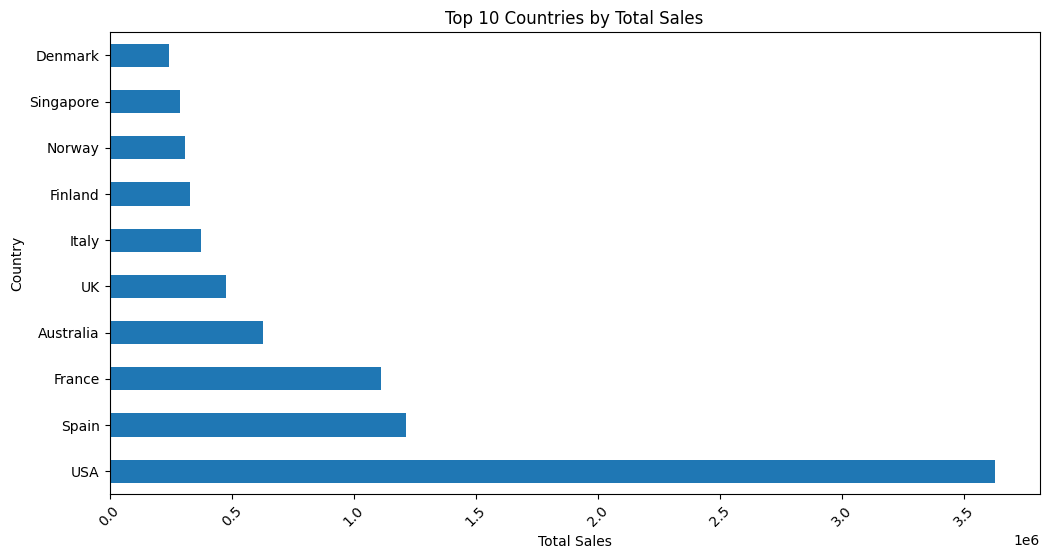

In [41]:
top_country.plot(kind='barh',figsize=(12,6))
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.title('Top 10 Countries by Total Sales')
plt.xticks(rotation=45)
plt.show()

In [48]:
product_sales=df['PRODUCTLINE']
product_sales

0       Motorcycles
1       Motorcycles
2       Motorcycles
3       Motorcycles
4       Motorcycles
           ...     
2818          Ships
2819          Ships
2820          Ships
2821          Ships
2822          Ships
Name: PRODUCTLINE, Length: 2823, dtype: object

In [49]:
product_sales_by_car=df.groupby('PRODUCTLINE')['SALES'].sum()
product_sales_by_car

PRODUCTLINE
Classic Cars        3919615.66
Motorcycles         1166388.34
Planes               975003.57
Ships                714437.13
Trains               226243.47
Trucks and Buses    1127789.84
Vintage Cars        1903150.84
Name: SALES, dtype: float64

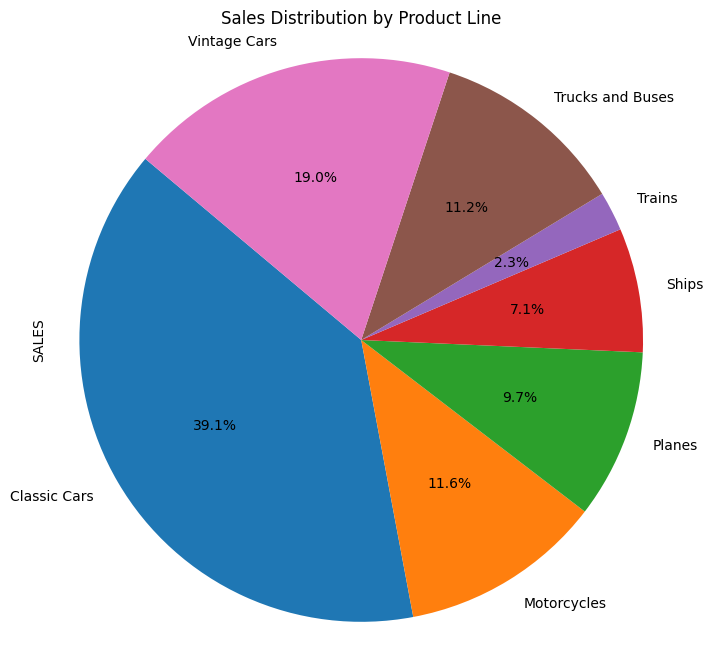

In [51]:
product_sales_by_car.plot(kind='pie', autopct='%1.1f%%', startangle=140, figsize=(8, 8))
plt.title('Sales Distribution by Product Line')
plt.axis('equal')
plt.show()


In [52]:
sales_by_status=df.groupby('STATUS')['SALES'].sum()
sales_by_status

STATUS
Cancelled      194487.48
Disputed        72212.86
In Process     144729.96
On Hold        178979.19
Resolved       150718.28
Shipped       9291501.08
Name: SALES, dtype: float64

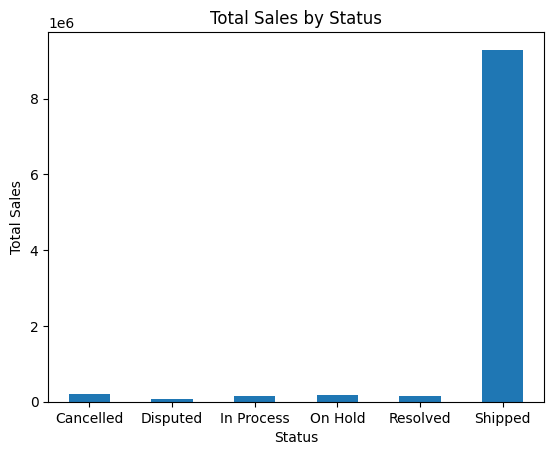

In [55]:
sales_by_status.plot(kind='bar')
plt.xlabel('Status')
plt.ylabel('Total Sales')
plt.title('Total Sales by Status')
plt.xticks(rotation=0)
plt.show()

In [66]:
top_customer=df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10)
top_customer

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64

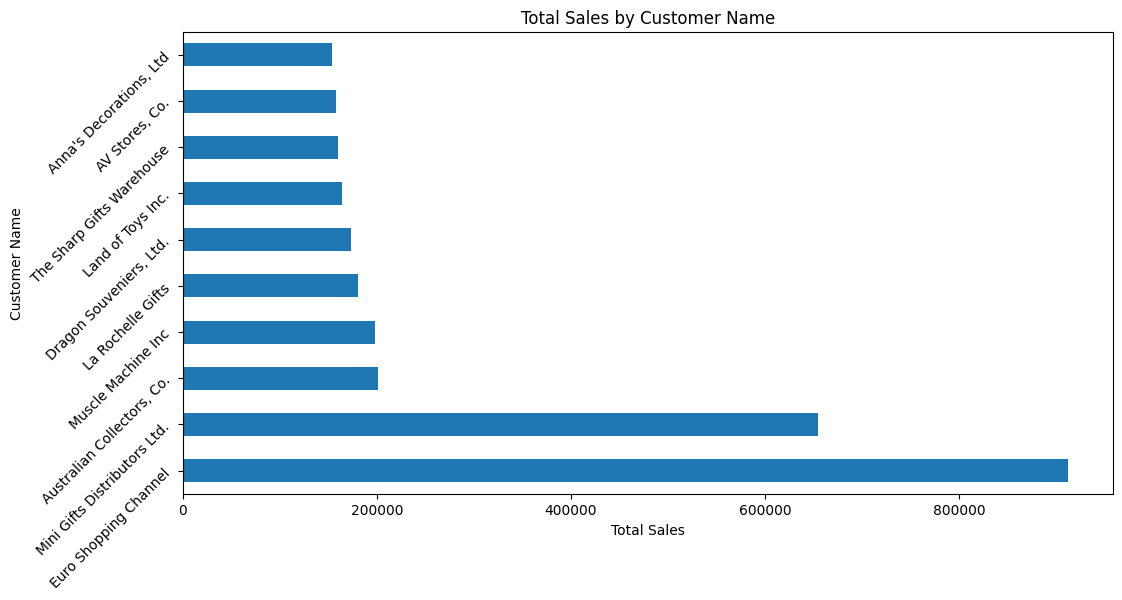

In [67]:
top_customer.plot(kind='barh',figsize=(12,6))
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.title('Total Sales by Customer Name')
plt.yticks(rotation=45)
plt.show()
